# BTM Score: Machine Learning-Based Discrimination of Beta-Thalassemia Minor from Iron Deficiency Anemia

This notebook implements the full analysis pipeline: descriptive statistics, 13 conventional discriminant indices, multicollinearity assessment, XGBoost and Elastic Net models evaluated by Monte Carlo cross-validation, SHAP-based feature selection, and the development and validation of the final BTM diagnostic score.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, binomtest, norm
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
import shap

pd.set_option("display.width", 120)
np.random.seed(42)

C:\Users\mayar\OneDrive\Desktop\ATUTEB 2026 (IDA vs BTM)\crispy-xylophone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading and Cleaning

The dataset is loaded once and used throughout the notebook. Diagnosis and sex labels are normalized (trimmed, lowercased) before being mapped to analysis-ready categories.

In [2]:
# Single data load (executed once for the entire notebook)
DATA_PATH = "data/base apres nettoyage.xlsx"

data = pd.read_excel(DATA_PATH)
data.columns = data.columns.str.strip()

# Clean text values BEFORE mapping
data["Diagnosis"] = data["Diagnosis"].astype(str).str.strip().str.lower()
data["Sex"] = data["Sex"].astype(str).str.strip().str.lower()

print("Unique values of Diagnosis after cleaning:")
print(data["Diagnosis"].value_counts())

DIAGNOSIS_MAP = {
    "iron deficiency anemia": ("IDA", 0),
    "beta-thalassemia minor": ("BTM", 1),
}

data["label"] = data["Diagnosis"].map(lambda d: DIAGNOSIS_MAP.get(d, (None, None))[0])
data["target"] = data["Diagnosis"].map(lambda d: DIAGNOSIS_MAP.get(d, (None, None))[1])

excluded = data[data["label"].isna()]
if len(excluded):
    print(f"\n{len(excluded)} row(s) outside the IDA/BTM cohort excluded (unrecognized diagnosis):")
    print(excluded["Diagnosis"].value_counts())

data = data.dropna(subset=["target"]).copy()
data["target"] = data["target"].astype(int)

print(f"\nFinal cohort: {len(data)} patients")
print(data["label"].value_counts())

Unique values of Diagnosis after cleaning:
Diagnosis
iron deficiency anemia    271
beta-thalassemia minor     60
Name: count, dtype: int64

Final cohort: 331 patients
label
IDA    271
BTM     60
Name: count, dtype: int64


## 3. Study Population Characteristics (Table I)

Age is compared with the Mann-Whitney U test and sex distribution with Fisher's exact test.

In [3]:
btm = data[data["label"] == "BTM"]
ida = data[data["label"] == "IDA"]

age_btm_mean, age_btm_sd = btm["Age"].mean(), btm["Age"].std()
age_ida_mean, age_ida_sd = ida["Age"].mean(), ida["Age"].std()
_, p_age = mannwhitneyu(btm["Age"].dropna(), ida["Age"].dropna())


def sex_counts(df):
    total = len(df)
    female = int((df["Sex"] == "f").sum())
    male = int((df["Sex"] == "m").sum())
    return female, male, total


btm_f, btm_m, btm_n = sex_counts(btm)
ida_f, ida_m, ida_n = sex_counts(ida)

contingency = pd.crosstab(data["label"], data["Sex"])
_, p_sex = stats.fisher_exact(contingency.values)

table1 = pd.DataFrame({
    "": ["Age (years)", "Sex - Female n(%)", "Sex - Male n(%)"],
    f"BTM (n={btm_n})": [
        f"{age_btm_mean:.1f} +/- {age_btm_sd:.1f}",
        f"{btm_f} ({btm_f/btm_n*100:.1f}%)",
        f"{btm_m} ({btm_m/btm_n*100:.1f}%)",
    ],
    f"IDA (n={ida_n})": [
        f"{age_ida_mean:.1f} +/- {age_ida_sd:.1f}",
        f"{ida_f} ({ida_f/ida_n*100:.1f}%)",
        f"{ida_m} ({ida_m/ida_n*100:.1f}%)",
    ],
    "p-value": [f"{p_age:.3f}", f"{p_sex:.3f}", ""],
})
print("Statistical test: Mann-Whitney U (age) and Fisher's exact test (sex)\n")
print(table1.to_string(index=False))

Statistical test: Mann-Whitney U (age) and Fisher's exact test (sex)

                     BTM (n=60)   IDA (n=271) p-value
      Age (years) 45.5 +/- 14.1 43.4 +/- 16.2   0.152
Sex - Female n(%)    47 (78.3%)   230 (84.9%)   0.246
  Sex - Male n(%)    13 (21.7%)    41 (15.1%)        


## 4. Comparison of Hematological Parameters (Table II)

`HEMATO_VARS` lists the 20 parameters used for modeling (indices, VIF, ML). WBC is deliberately excluded from modeling, since it is mathematically the sum of NEUT + LYMPH + MONO + EO + BASO (already included separately), which would create near-perfect collinearity. It is nonetheless reported descriptively in Table II (`TABLE2_VARS`) for a complete blood count profile.

In [4]:
HEMATO_VARS = [
    "RBC", "Hb", "HCT", "MCV", "MCH", "MCHC",
    "PLT", "RDW-SD", "RDW-CV",
    "NEUT", "LYMPH", "MONO", "EO", "BASO",
    "RET %", "RET absolute",
    "IRF", "LFR", "MFR", "HFR",
]
TABLE2_VARS = ["WBC"] + HEMATO_VARS

UNIT_CONVERSIONS = {
    "WBC": 1e3, "PLT": 1e3, "NEUT": 1e3, "LYMPH": 1e3, "MONO": 1e3, "EO": 1e3, "BASO": 1e3,
    "RET absolute": 1e6,
}
UNIT_LABELS = {
    "WBC": " (x10^3/uL)", "PLT": " (x10^3/uL)", "NEUT": " (x10^3/uL)", "LYMPH": " (x10^3/uL)",
    "MONO": " (x10^3/uL)", "EO": " (x10^3/uL)", "BASO": " (x10^3/uL)",
    "RET absolute": " (x10^6/uL)",
}


def median_iqr(x):
    x = x.dropna()
    return f"{x.median():.2f} ({x.quantile(0.25):.2f}-{x.quantile(0.75):.2f})"


rows = []
for var in TABLE2_VARS:
    if var not in data.columns:
        continue
    factor = UNIT_CONVERSIONS.get(var, 1)
    ida_vals = ida[var] / factor
    btm_vals = btm[var] / factor
    if ida_vals.dropna().shape[0] < 3 or btm_vals.dropna().shape[0] < 3:
        continue
    _, p = mannwhitneyu(ida_vals.dropna(), btm_vals.dropna())
    rows.append({
        "Feature": var + UNIT_LABELS.get(var, ""),
        "IDA (Median [Q1-Q3])": median_iqr(ida_vals),
        "BTM (Median [Q1-Q3])": median_iqr(btm_vals),
        "p-value": "<0.001" if p < 0.001 else f"{p:.3f}",
    })

table2 = pd.DataFrame(rows)
print(table2.to_string(index=False))

                Feature   IDA (Median [Q1-Q3])   BTM (Median [Q1-Q3]) p-value
         WBC (x10^3/uL)       6.00 (4.92-7.36)       7.05 (5.70-9.20)  <0.001
                    RBC       4.27 (3.83-4.56)       5.19 (4.81-5.60)  <0.001
                     Hb       8.50 (7.05-9.60)     10.30 (9.60-11.10)  <0.001
                    HCT    29.10 (25.25-31.90)    31.35 (30.15-34.15)  <0.001
                    MCV    67.70 (64.10-73.45)    61.10 (59.42-65.03)  <0.001
                    MCH    19.70 (17.55-22.10)    19.65 (19.10-20.70)   0.795
                   MCHC    29.00 (27.45-30.70)    32.35 (31.77-32.90)  <0.001
         PLT (x10^3/uL) 294.00 (237.00-370.50) 221.50 (173.25-274.25)  <0.001
                 RDW-SD    46.10 (42.75-51.42)    35.80 (34.48-38.10)  <0.001
                 RDW-CV    19.70 (17.92-22.27)    17.10 (15.97-18.32)  <0.001
        NEUT (x10^3/uL)       3.37 (2.54-4.27)       4.21 (2.77-5.66)   0.002
       LYMPH (x10^3/uL)       1.91 (1.49-2.25)       2.17 (1.76-

## 5. Conventional Discriminant Indices

### 5.1 Index Definitions and Formulas

All 13 indices are defined below with their original formula, published cutoff, and discrimination direction, verified against their original source publications (see Methods for full references). Published cutoffs are retained as originally reported, even where the discriminative direction did not match this cohort.

In [5]:
INDEX_DEFINITIONS = {
    "Mentzer":    (lambda d: d["MCV"] / d["RBC"],                                13,    "below"),
    "RDWI":       (lambda d: (d["MCV"] * d["RDW-CV"]) / d["RBC"],                220,   "below"),
    "Srivastava": (lambda d: d["MCH"] / d["RBC"],                                3.8,   "below"),
    "S&L":        (lambda d: (d["MCV"] ** 2 * d["MCH"]) / 100,                   1530,  "below"),
    "E&F":        (lambda d: d["MCV"] - d["RBC"] - (5 * d["Hb"]) - 3.4,          0,     "below"),
    "G&K":        (lambda d: (d["MCV"] ** 2 * d["RDW-CV"]) / (d["Hb"] * 100),    65,    "below"),
    "Ricerca":    (lambda d: d["RDW-CV"] / d["RBC"],                             4.4,   "below"),
    "Sirdah":     (lambda d: d["MCV"] - d["RBC"] - (3 * d["Hb"]),                27,    "below"),
    "Ehsani":     (lambda d: d["MCV"] - (10 * d["RBC"]),                        15,     "below"),
    # CRUISE = MCHC + 0.603*RBC + 0.523*RDW-CV, cutoff 42.63
    # (Hans A, Atreja CB, Batra N. Cureus. 2024;16(7):e64048 ;
    #  Jahangiri M, Rahim F, Malehi AS. Sci Rep. 2019;9(1):18610)
    "CRUISE":     (lambda d: d["MCHC"] + 0.603 * d["RBC"] + 0.523 * d["RDW-CV"], 42.63, "above"),
    # MDHL = MCH*RBC/MCV, cutoff 1.67 (Telmissani OA et al. Lab Hematol. 1999;5:149-52)
    "MDHL":       (lambda d: (d["MCH"] * d["RBC"]) / d["MCV"],                   1.67,  "above"),
    # Huber-Herklotz = (MCH*RDW*0.1/RBC)+RDW, cutoff 22
    # (Huber A et al. Forum Med Suisse. 2004;4:947-952)
    # Originally designed for alpha-thalassemia -> lower performance is
    # expected here (beta-thalassemia cohort); noted in the Discussion.
    "HH":         (lambda d: (d["MCH"] * d["RDW-CV"] * 0.1 / d["RBC"]) + d["RDW-CV"], 22, "below"),
    # MCHD = MCH/MCV, cutoff 0.34, BTM if <0.34 (Telmissani OA et al., 1999)
    # Original direction kept as published, even though it underperforms on
    # this specific cohort (see Discussion / limitations).
    "MCHD":       (lambda d: d["MCH"] / d["MCV"],                                0.34,  "below"),
}


def index_score(d, name):
    """Returns a value where higher = more likely BTM."""
    formula, _, direction = INDEX_DEFINITIONS[name]
    value = formula(d)
    return value if direction == "above" else -value


indices = pd.DataFrame(index=data.index)
for name, (formula, cutoff, direction) in INDEX_DEFINITIONS.items():
    value = formula(data)
    indices[name] = value
    indices[f"{name}_pred"] = (
        (value > cutoff) if direction == "above" else (value < cutoff)
    ).astype(int)
indices["target"] = data["target"].values

### 5.2 Univariate Performance (Single Cutoff)

In [6]:
rows = []
for name in INDEX_DEFINITIONS:
    mask = indices[name].notna()
    y_true = indices.loc[mask, "target"]
    y_pred = indices.loc[mask, f"{name}_pred"]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    acc = (tp + tn) / len(y_true)
    auc = roc_auc_score(y_true, index_score(data.loc[mask], name))
    rows.append({
        "Index": name, "Sensitivity (%)": round(sens * 100, 1),
        "Specificity (%)": round(spec * 100, 1), "Accuracy": round(acc, 3),
        "AUC": round(auc, 3),
    })

index_perf = pd.DataFrame(rows).sort_values("AUC", ascending=False)
print("Univariate evaluation of each index (single cutoff, before modeling):\n")
print(index_perf.to_string(index=False))

Univariate evaluation of each index (single cutoff, before modeling):

     Index  Sensitivity (%)  Specificity (%)  Accuracy   AUC
       G&K             61.7             98.9     0.919 0.970
       E&F             41.7            100.0     0.894 0.960
    Sirdah             58.3             98.5     0.912 0.957
      RDWI             76.7             98.5     0.944 0.955
      MDHL             55.0            100.0     0.918 0.952
   Ricerca             95.0             58.0     0.649 0.928
   Mentzer             66.7             93.4     0.885 0.914
    Ehsani             63.3             90.8     0.858 0.910
        HH             18.3             98.9     0.839 0.891
    CRUISE             85.0             62.2     0.665 0.803
Srivastava             51.7             88.6     0.819 0.790
       S&L            100.0              4.1     0.215 0.677
      MCHD             98.3              0.7     0.184 0.098


## 6. Feature Set for Machine Learning

The 20 hematological parameters in `HEMATO_VARS` are used as model inputs (Age and WBC are not part of the CBC-derived feature set). Missing values are imputed with the cohort median.

In [7]:
FEATURES = HEMATO_VARS

missing_counts = data[FEATURES].isnull().sum()
print("Missing values per variable (full cohort):")
print(missing_counts[missing_counts > 0] if missing_counts.any() else "None")

X = data[FEATURES].copy()
y = data["target"].copy()

X = X.fillna(X.median())

print(f"\nX: {X.shape}, y: {y.shape}")

Missing values per variable (full cohort):
RDW-SD    9
RDW-CV    9
NEUT      1
LYMPH     1
MONO      1
EO        1
BASO      1
HFR       1
dtype: int64

X: (331, 20), y: (331,)


## 7. Multicollinearity Assessment (VIF)

Variance inflation factor computed on the seven red-cell parameters that are mathematically or physiologically interdependent.

In [8]:
VIF_FEATURES = ["RBC", "Hb", "HCT", "MCV", "MCH", "MCHC", "RDW-CV"]
X_vif = X[VIF_FEATURES]

vif_data = pd.DataFrame({
    "Variable": VIF_FEATURES,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False)

print(vif_data.to_string(index=False))
print("\nVIF < 1.5: significant multicollinearity is absent")
print("VIF 1-5: moderate collinearity, generally not considered problematic")
print("VIF > 10: severe multicollinearity, may require corrective action")

Variable         VIF
     MCH 8522.678532
     HCT 5531.224053
      Hb 4441.453336
     MCV 4182.225759
    MCHC 3322.384217
     RBC 3126.777506
  RDW-CV   46.586099

VIF < 1.5: significant multicollinearity is absent
VIF 1-5: moderate collinearity, generally not considered problematic
VIF > 10: severe multicollinearity, may require corrective action


## 8. Machine Learning Models

### 8.1 Model Definitions

XGBoost and Elastic Net (logistic regression with combined L1/L2 penalty) are defined once and reused throughout the notebook.

In [9]:
def make_xgboost():
    return XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        eval_metric="auc", random_state=42,
    )


def make_elastic_net():
    # l1_ratio in (0, 1) implies elastic-net (L1+L2) regularization with the
    # saga solver; "penalty=" is not passed explicitly (deprecated in recent
    # scikit-learn versions).
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="saga", l1_ratio=0.5,
            max_iter=10000, random_state=42,
        )),
    ])


def youden_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    return thresholds[np.argmax(tpr - fpr)]


def binary_metrics(y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    npv = tn / (tn + fn) if (tn + fn) else 0.0
    acc = (tp + tn) / (tp + tn + fp + fn)
    f1 = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0
    auc = roc_auc_score(y_true, y_proba)
    return dict(accuracy=acc, sensitivity=sens, specificity=spec,
                precision=prec, npv=npv, f1=f1, auc=auc)

### 8.2 Monte Carlo Cross-Validation (1,000 Iterations)

For each of 1,000 stratified 80%/20% splits, both models and all 13 conventional indices are evaluated on the same held-out 20% test set, ensuring a fair, identically-resampled comparison. Reported performance is always the average across the 1,000 test-set evaluations (train-set performance is never used for reporting).

In [10]:
N_ITER = 1000
cv = StratifiedShuffleSplit(n_splits=N_ITER, test_size=0.2, random_state=42)

model_metrics = {"XGBoost": [], "Elastic Net": []}
index_metrics = {name: [] for name in INDEX_DEFINITIONS}

for train_idx, test_idx in cv.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    for label, make_model in [("XGBoost", make_xgboost), ("Elastic Net", make_elastic_net)]:
        model = make_model()
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        thr = youden_threshold(y_test, proba)
        pred = (proba > thr).astype(int)
        model_metrics[label].append(binary_metrics(y_test, pred, proba))

    data_test = data.loc[X_test.index]
    indices_test = indices.loc[X_test.index]
    for name in INDEX_DEFINITIONS:
        mask = data_test[["RBC", "MCV", "Hb", "MCH", "RDW-CV"]].notna().all(axis=1)
        if mask.sum() < 2:
            continue
        y_test_masked = y_test[mask]
        if len(np.unique(y_test_masked)) < 2:
            continue
        score = index_score(data_test[mask], name)
        pred_idx = indices_test.loc[mask, f"{name}_pred"]
        index_metrics[name].append(binary_metrics(y_test_masked, pred_idx, score))


def summarize(values, key):
    arr = np.array([v[key] for v in values])
    return arr.mean(), max(0, arr.mean() - 1.96 * arr.std()), min(1, arr.mean() + 1.96 * arr.std())


for label in ["XGBoost", "Elastic Net"]:
    auc_mean, auc_lo, auc_hi = summarize(model_metrics[label], "auc")
    print(f"{label}: AUC = {auc_mean:.3f} (95% CI [{auc_lo:.3f}-{auc_hi:.3f}])")

XGBoost: AUC = 0.984 (95% CI [0.954-1.000])
Elastic Net: AUC = 0.987 (95% CI [0.951-1.000])


### 8.3 ROC Curves and Confusion Matrices

For each model: (A) the confusion matrix shows the mean count per iteration (rounded), directly consistent with the averaged sensitivity/specificity reported above; (B) the ROC curve shows the mean sensitivity across the 1,000 test-set iterations at each specificity level (green line), with the grey band showing the 95% interval across iterations.

In [ ]:
fpr_grid = np.linspace(0, 1, 200)
roc_cm_results = {
    "XGBoost": {"tprs": [], "aucs": [], "cm": np.zeros((2, 2), dtype=int)},
    "Elastic Net": {"tprs": [], "aucs": [], "cm": np.zeros((2, 2), dtype=int)},
}

cv_fig = StratifiedShuffleSplit(n_splits=N_ITER, test_size=0.2, random_state=42)
for train_idx, test_idx in cv_fig.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    for label, make_model in [("XGBoost", make_xgboost), ("Elastic Net", make_elastic_net)]:
        model = make_model()
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, proba)
        interp_tpr = np.interp(fpr_grid, fpr, tpr)
        interp_tpr[0] = 0.0
        roc_cm_results[label]["tprs"].append(interp_tpr)
        roc_cm_results[label]["aucs"].append(roc_auc_score(y_test, proba))

        thr = youden_threshold(y_test, proba)
        pred = (proba > thr).astype(int)
        roc_cm_results[label]["cm"] += confusion_matrix(y_test, pred, labels=[0, 1])

model_titles = {"XGBoost": "XGBoost model", "Elastic Net": "Elastic Net model"}

for label in ["XGBoost", "Elastic Net"]:
    tprs = np.array(roc_cm_results[label]["tprs"])
    mean_tpr = tprs.mean(axis=0)
    mean_tpr[-1] = 1.0
    lo = np.percentile(tprs, 2.5, axis=0)
    hi = np.percentile(tprs, 97.5, axis=0)
    aucs = np.array(roc_cm_results[label]["aucs"])
    mean_auc = aucs.mean()
    auc_lo = max(0.0, mean_auc - 1.96 * aucs.std())
    auc_hi = min(1.0, mean_auc + 1.96 * aucs.std())
    cm_mean = np.round(roc_cm_results[label]["cm"] / N_ITER).astype(int)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    sns.heatmap(cm_mean, annot=True, fmt="d", cmap="Blues",
                xticklabels=["IDA", "BTM"], yticklabels=["IDA", "BTM"],
                cbar=True, ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_title("Confusion matrix")

    axes[1].plot(fpr_grid, mean_tpr, color="green", lw=2,
                 label=f"AUROC = {mean_auc:.2f} (95% CI [{auc_lo:.2f}-{auc_hi:.2f}])")
    axes[1].fill_between(fpr_grid, lo, hi, color="grey", alpha=0.3)
    axes[1].plot([0, 1], [0, 1], linestyle="--", color="black")
    axes[1].set_xlabel("1 - Specificity")
    axes[1].set_ylabel("Sensitivity")
    axes[1].set_title("ROC curve")
    axes[1].legend(loc="lower right")

    fig.suptitle(model_titles[label], fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.show()

## 9. SHAP Feature Importance

SHAP is applied to XGBoost (rather than Elastic Net) because its coefficients are not directly interpretable, unlike Elastic Net's linear coefficients. The top 3 features by mean absolute SHAP value are carried forward to build the diagnostic score.

In [ ]:
xgb_full = make_xgboost()
xgb_full.fit(X, y)

explainer = shap.Explainer(xgb_full)
shap_values = explainer(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.sca(axes[0])
shap.plots.bar(shap_values, show=False, ax=axes[0])
axes[0].set_title("Mean absolute SHAP value")

plt.sca(axes[1])
shap.plots.beeswarm(shap_values, show=False, ax=axes[1], plot_size=None)
axes[1].set_title("SHAP value distribution")

plt.tight_layout()
plt.show()

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(shap_values.values).mean(axis=0),
}).sort_values("Importance", ascending=False)

print(shap_importance.to_string(index=False))

SCORE_FEATURES = shap_importance["Feature"].head(3).tolist()
print(f"
Variables selected for the diagnostic score (top 3 SHAP features): {SCORE_FEATURES}")

## 10. BTM Score Development

### 10.1 Score Construction (70% Training Set)

The final score must be a single fixed formula, trained only on the 70% training set and never evaluated on the data used to build it. The linear predictor z is converted to a probability via the sigmoid function before being compared to any decision threshold.

In [13]:
X_train70, X_val30, y_train70, y_val30 = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_score_train = X_train70[SCORE_FEATURES]
X_score_val = X_val30[SCORE_FEATURES]

scaler_score = StandardScaler()
X_score_train_scaled = scaler_score.fit_transform(X_score_train)
X_score_val_scaled = scaler_score.transform(X_score_val)

model_score = LogisticRegression(max_iter=1000, random_state=42)
model_score.fit(X_score_train_scaled, y_train70)

coef_std = model_score.coef_[0]
intercept_std = model_score.intercept_[0]

means = scaler_score.mean_
stds = scaler_score.scale_
coef_raw = coef_std / stds
intercept_raw = intercept_std - np.sum(coef_std * means / stds)

def fmt_coef(c):
    # Enough significant digits so that variables on a large raw scale
    # (e.g. RET absolute, in units/uL) don't display a misleading "0.0000"
    # when the coefficient is simply very small.
    return f"{abs(c):.4f}" if abs(c) >= 0.001 else f"{abs(c):.3e}"


terms = " ".join(f"{'+' if c >= 0 else '-'} {fmt_coef(c)}*{f}" for f, c in zip(SCORE_FEATURES, coef_raw))
intercept_term = f"{'+' if intercept_raw >= 0 else '-'} {abs(intercept_raw):.4f}"

print("===== STEP 1: logit (z) - linear combination, raw values =====")
print(f"z = {terms} {intercept_term}")
print("Note: z is NOT a probability (it is not bounded between 0 and 1).")

print("\n===== STEP 2: BTM probability (sigmoid of z) =====")
print("P(BTM) = 1 / (1 + exp(-z))")
print("This probability is what must be compared to the decision threshold, not z directly.")

score_std_method = model_score.decision_function(X_score_train_scaled)
score_raw_method = np.dot(X_score_train.values, coef_raw) + intercept_raw
equivalent = np.allclose(score_std_method, score_raw_method, atol=1e-8)
print(f"\n(check: standardized and raw formulas give the same z: {equivalent})")

print("\n===== WORKED EXAMPLE (median patient of each group) =====")
for group_label in ["IDA", "BTM"]:
    typical = data.loc[data["label"] == group_label, SCORE_FEATURES].median()
    z_typical = float(np.dot(typical.values, coef_raw) + intercept_raw)
    p_typical = 1 / (1 + np.exp(-z_typical))
    values_str = ", ".join(f"{f}={typical[f]:.2f}" for f in SCORE_FEATURES)
    print(f"Median {group_label} patient ({values_str}): z = {z_typical:.3f} -> P(BTM) = {p_typical:.4f}")

proba_train70 = model_score.predict_proba(X_score_train_scaled)[:, 1]
proba_val30 = model_score.predict_proba(X_score_val_scaled)[:, 1]

===== STEP 1: logit (z) - linear combination, raw values =====
z = - 0.2629*RDW-SD + 0.6656*MCHC + 4.881e-05*RET absolute - 14.2434
Note: z is NOT a probability (it is not bounded between 0 and 1).

===== STEP 2: BTM probability (sigmoid of z) =====
P(BTM) = 1 / (1 + exp(-z))
This probability is what must be compared to the decision threshold, not z directly.

(check: standardized and raw formulas give the same z: True)

===== WORKED EXAMPLE (median patient of each group) =====
Median IDA patient (RDW-SD=46.10, MCHC=29.00, RET absolute=45300.00): z = -4.848 -> P(BTM) = 0.0078
Median BTM patient (RDW-SD=35.80, MCHC=32.35, RET absolute=93450.00): z = 2.440 -> P(BTM) = 0.9198


### 10.2 Decision Threshold (Youden Index)

The threshold is computed only on the 70% training set, then applied unchanged to the validation set. It applies to P(BTM), not to the raw logit z.

In [14]:
score_threshold = youden_threshold(y_train70, proba_train70)
print(f"Optimal threshold (Youden index) on P(BTM) = {score_threshold:.4f}")
print("(computed only on the 70% training set, then applied unchanged to the validation set)")

Optimal threshold (Youden index) on P(BTM) = 0.3496
(computed only on the 70% training set, then applied unchanged to the validation set)


### 10.3 Validation on the Held-Out 30%

These patients were never used to build or tune the score.

In [ ]:
label_map = {0: "IDA", 1: "BTM"}

y_pred_val30 = (proba_val30 > score_threshold).astype(int)
metrics_score = binary_metrics(y_val30, y_pred_val30, proba_val30)

n1 = int((y_val30 == 1).sum())
n0 = int((y_val30 == 0).sum())
auc_val = metrics_score["auc"]
Q1 = auc_val / (2 - auc_val)
Q2 = 2 * auc_val ** 2 / (1 + auc_val)
se_auc = np.sqrt((auc_val * (1 - auc_val) + (n1 - 1) * (Q1 - auc_val ** 2)
                  + (n0 - 1) * (Q2 - auc_val ** 2)) / (n0 * n1))
if se_auc == 0:
    p_value_score = 0.0
else:
    z = (auc_val - 0.5) / se_auc
    p_value_score = 2 * (1 - norm.cdf(abs(z)))

comparison_val = pd.DataFrame({
    "True diagnosis": y_val30.map(label_map).values,
    "Predicted diagnosis": pd.Series(y_pred_val30, index=y_val30.index).map(label_map).values,
    "P(BTM)": proba_val30,
})

cm_score = confusion_matrix(y_val30, y_pred_val30)
cm_score_df = pd.DataFrame(cm_score, index=["True IDA", "True BTM"], columns=["Predicted IDA", "Predicted BTM"])
print("===== True vs. predicted, validation set (n={}, never seen during training) =====
".format(len(y_val30)))
print(cm_score_df)

n_correct_val = int((y_pred_val30 == y_val30.values).sum())
print(f"
Correctly classified patients: {n_correct_val}/{len(y_val30)} ({metrics_score['accuracy']*100:.1f}%)")
print(f"Sensitivity (BTM detected): {metrics_score['sensitivity']*100:.1f}%")
print(f"Specificity (IDA detected): {metrics_score['specificity']*100:.1f}%")
print(f"AUC: {auc_val:.4f} (p-value vs 0.5: {p_value_score:.2e})")

print("
===== Patient-level excerpt (first 10, validation set) =====
")
print(comparison_val.head(10).to_string())

fpr, tpr, _ = roc_curve(y_val30, proba_val30)
n_boot = 1000
rng = np.random.RandomState(42)
mean_fpr = np.linspace(0, 1, 100)
tprs = []
y_val30_arr = y_val30.values
for _ in range(n_boot):
    idx = rng.randint(0, len(y_val30_arr), len(y_val30_arr))
    if len(np.unique(y_val30_arr[idx])) < 2:
        continue
    f, t, _ = roc_curve(y_val30_arr[idx], proba_val30[idx])
    ti = np.interp(mean_fpr, f, t)
    ti[0] = 0.0
    tprs.append(ti)
mean_tpr = np.mean(tprs, axis=0)
std_tpr = np.std(tprs, axis=0)
upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.heatmap(cm_score_df, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix")

axes[1].plot(mean_fpr, mean_tpr, color="green", label=f"BTM score (AUC={auc_val:.3f})")
axes[1].fill_between(mean_fpr, lower, upper, color="gray", alpha=0.3)
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("1 - Specificity")
axes[1].set_ylabel("Sensitivity")
axes[1].set_title("ROC curve")
axes[1].legend(loc="lower right")

fig.suptitle("BTM score", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

### 10.4 Robustness Check (50 Random Splits)

The official 70/30 split (seed 42) is compared against 50 additional random splits, using the same 3 score variables and recalculating the threshold each time, to confirm the result is not a lucky split.

Score robustness across 50 different 70/30 splits (same 3 variables, threshold recalculated each time):

       accuracy  sensitivity  specificity      auc
count   50.0000      50.0000      50.0000  50.0000
mean     0.9588       0.9300       0.9651   0.9869
std      0.0240       0.0548       0.0341   0.0159
min      0.8800       0.8333       0.8537   0.9512
25%      0.9525       0.8889       0.9543   0.9885
50%      0.9600       0.9444       0.9756   0.9939
75%      0.9700       0.9861       0.9878   0.9959
max      1.0000       1.0000       1.0000   1.0000

AUC >= 0.999 in 8/50 splits
Official seed (42): AUC = 0.9892


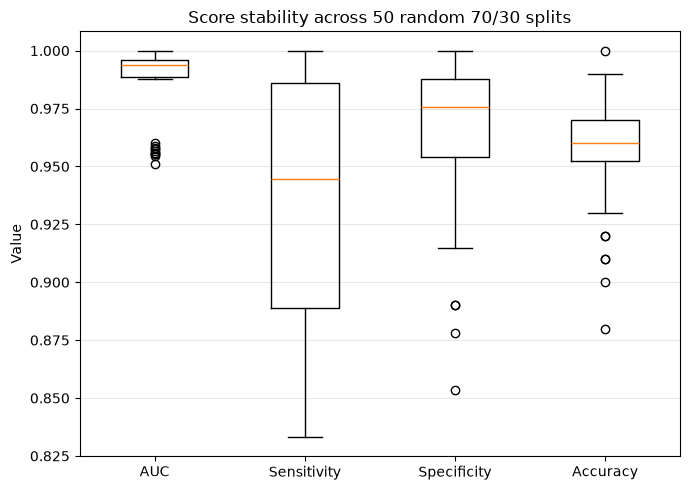

In [16]:
N_ROBUSTNESS = 50
robustness_rows = []

for seed in range(N_ROBUSTNESS):
    Xr_train, Xr_val, yr_train, yr_val = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed
    )

    Xr_score_train = Xr_train[SCORE_FEATURES]
    Xr_score_val = Xr_val[SCORE_FEATURES]

    scaler_r = StandardScaler()
    Xr_train_scaled = scaler_r.fit_transform(Xr_score_train)
    Xr_val_scaled = scaler_r.transform(Xr_score_val)

    model_r = LogisticRegression(max_iter=1000, random_state=42)
    model_r.fit(Xr_train_scaled, yr_train)

    proba_r_train = model_r.predict_proba(Xr_train_scaled)[:, 1]
    proba_r_val = model_r.predict_proba(Xr_val_scaled)[:, 1]

    thr_r = youden_threshold(yr_train, proba_r_train)
    pred_r_val = (proba_r_val > thr_r).astype(int)

    m = binary_metrics(yr_val, pred_r_val, proba_r_val)
    m["seed"] = seed
    robustness_rows.append(m)

robustness_df = pd.DataFrame(robustness_rows)

print(f"Score robustness across {N_ROBUSTNESS} different 70/30 splits (same 3 variables, threshold recalculated each time):\n")
print(robustness_df[["accuracy", "sensitivity", "specificity", "auc"]].describe().round(4).to_string())

n_perfect_auc = (robustness_df["auc"] >= 0.999).sum()
print(f"\nAUC >= 0.999 in {n_perfect_auc}/{N_ROBUSTNESS} splits")
print(f"Official seed (42): AUC = {robustness_df.loc[robustness_df['seed'] == 42, 'auc'].values[0]:.4f}")

plt.figure(figsize=(7, 5))
plt.boxplot(
    [robustness_df["auc"], robustness_df["sensitivity"], robustness_df["specificity"], robustness_df["accuracy"]],
    tick_labels=["AUC", "Sensitivity", "Specificity", "Accuracy"],
)
plt.title(f"Score stability across {N_ROBUSTNESS} random 70/30 splits")
plt.ylabel("Value")
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 11. Comparative Summary

A single summary table combining the two ML models (Monte Carlo average), the 13 conventional indices (Monte Carlo average, identical resampling), and the final BTM score (single 70/30 validation).

### 11.1 Comparative Performance Metrics of BTM Score and Conventional Indices

In [17]:
summary_rows = []
nir = max(y.mean(), 1 - y.mean())

for label in ["XGBoost", "Elastic Net"]:
    m = model_metrics[label]
    acc_mean, acc_lo, acc_hi = summarize(m, "accuracy")
    auc_mean, auc_lo, auc_hi = summarize(m, "auc")
    p_val = binomtest(int(acc_mean * len(y)), len(y), nir, alternative="greater").pvalue
    summary_rows.append({
        "Model": label,
        "Accuracy": acc_mean,
        "Sensitivity": np.mean([x["sensitivity"] for x in m]),
        "Specificity": np.mean([x["specificity"] for x in m]),
        "Precision": np.mean([x["precision"] for x in m]),
        "NPV": np.mean([x["npv"] for x in m]),
        "F1": np.mean([x["f1"] for x in m]),
        "AUC": auc_mean, "AUC_low": auc_lo, "AUC_high": auc_hi,
        "CER": 1 - acc_mean, "p-value": p_val,
    })

for name in INDEX_DEFINITIONS:
    m = index_metrics[name]
    acc_mean, acc_lo, acc_hi = summarize(m, "accuracy")
    auc_mean, auc_lo, auc_hi = summarize(m, "auc")
    p_val = binomtest(int(acc_mean * len(y)), len(y), nir, alternative="greater").pvalue
    summary_rows.append({
        "Model": name,
        "Accuracy": acc_mean,
        "Sensitivity": np.mean([x["sensitivity"] for x in m]),
        "Specificity": np.mean([x["specificity"] for x in m]),
        "Precision": np.mean([x["precision"] for x in m]),
        "NPV": np.mean([x["npv"] for x in m]),
        "F1": np.mean([x["f1"] for x in m]),
        "AUC": auc_mean, "AUC_low": auc_lo, "AUC_high": auc_hi,
        "CER": 1 - acc_mean, "p-value": p_val,
    })

summary_rows.append({
    "Model": "BTM score",
    "Accuracy": metrics_score["accuracy"], "Sensitivity": metrics_score["sensitivity"],
    "Specificity": metrics_score["specificity"], "Precision": metrics_score["precision"],
    "NPV": metrics_score["npv"], "F1": metrics_score["f1"], "AUC": metrics_score["auc"],
    "AUC_low": np.nan, "AUC_high": np.nan, "CER": 1 - metrics_score["accuracy"],
    "p-value": p_value_score,
})

summary_df = pd.DataFrame(summary_rows).sort_values("AUC", ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

      Model  Accuracy  Sensitivity  Specificity  Precision      NPV       F1      AUC  AUC_low  AUC_high      CER      p-value
  BTM score  0.960000     0.888889     0.975610   0.888889 0.975610 0.888889 0.989160      NaN       NaN 0.040000 0.000000e+00
Elastic Net  0.960642     0.898583     0.974182   0.893783 0.977843 0.893370 0.987074 0.950710  1.000000 0.039358 2.470770e-14
    XGBoost  0.947119     0.874500     0.962964   0.859515 0.972517 0.860744 0.984092 0.953975  1.000000 0.052881 8.638290e-12
        G&K  0.920276     0.618417     0.988413   0.927749 0.920541 0.733589 0.970735 0.919887  1.000000 0.079724 2.038797e-07
        E&F  0.893301     0.420500     1.000000   1.000000 0.884913 0.580652 0.961541 0.913993  1.000000 0.106699 1.953660e-04
     Sirdah  0.912233     0.588083     0.985369   0.905745 0.914458 0.704609 0.957372 0.907410  1.000000 0.087767 2.735769e-06
       RDWI  0.944446     0.768917     0.984072   0.920031 0.950248 0.832358 0.956573 0.891387  1.000000 0.0555

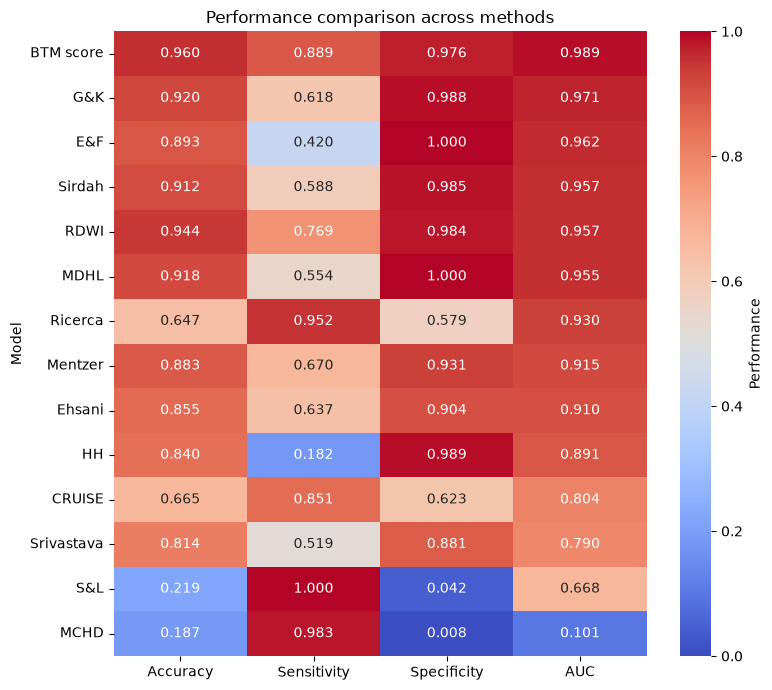

In [18]:
# Table I.1 / heatmap for this subsection: BTM score vs. the 13 conventional
# indices only (the 2 ML models have their own dedicated figures in Section 8.3).
score_vs_indices = summary_df[summary_df["Model"] != "XGBoost"]
score_vs_indices = score_vs_indices[score_vs_indices["Model"] != "Elastic Net"]

heatmap_df = score_vs_indices.set_index("Model")[["Accuracy", "Sensitivity", "Specificity", "AUC"]].dropna()

plt.figure(figsize=(8, max(4, 0.5 * len(heatmap_df))))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="coolwarm", vmin=0, vmax=1,
            cbar_kws={"label": "Performance"})
plt.title("Performance comparison across methods")
plt.tight_layout()
plt.show()

### 11.2 Comparison of Performance Metrics of the BTM Score with Other Published Studies

The BTM score is compared against five recently published discrimination scores for IDA vs. beta-thalassemia (trait), each built with a similar logistic-regression or machine-learning approach on CBC-derived indices. Values below are taken directly from each publication (not recomputed on our cohort), so they reflect performance on each study's own population, not a head-to-head validation on the same patients.

- **Basrah Score** (Mahmood SA, Khalaf AA, Hamadi SS. Front Big Data. 2025;8:1634133) - Elastic Net logistic regression on Sex, Age, Hb, RBC, MCV, MCH, MCHC; n = 2120 (1080 IDA / 1040 BTT), Basrah, Iraq.
- **Karbala formula** (Al-Najafi WK, Attiyah MN, Abd HM. Karbala J Med. 2022;15(1):2564-70) - binary logistic regression on HGB, HCT, MCV, ln(RDW); n = 1380 (802 IDA / 578 BTT), Karbala, Iraq.
- **TIDI** (Pan L, Li L, Qiu Y, et al. Medicine. 2024;103(20):e38205) - Fisher discriminant analysis on RBC, Hb, MCHC, RET%; n = 598 (278 IDA / 320 TT), Guangxi, China.
- **Schipper et al.** (Schipper A, Rutten M, van Gammeren A, et al. Clin Chem. 2024;70(8):1064-75) - XGBoost / logistic regression on Hb, MCV, MCH, MCHC, RDW-CV, RBC, platelets; external validation for thalassemia vs. IDA on n = 2629 (1259 IDA / 1370 thalassemia), the Netherlands/Spain.
- **ThalPred** (Laengsri V, Shoombuatong W, Adirojananon W, et al. BMC Med Inform Decis Mak. 2019;19:212) - support vector machine on RBC, Hb, Hct, MCV, MCH, MCHC, RDW; external validation on n = 186 (40 IDA / 146 TT), Thailand.

In [19]:
# ===== Literature comparison: values taken directly from each publication =====
# (not recomputed on our cohort - see citations above). Where a 95% CI was not
# reported, it is approximated from the reported SD (mean +/- 1.96*SD) and
# flagged; where neither was reported, only the point estimate is shown.
literature_scores = [
    {"Study": "This study (BTM score)", "Population": "Tunisia (n=331)",
     "Method": "XGBoost + Elastic Net (SHAP-selected), 70/30 split",
     "AUC": metrics_score["auc"], "AUC_low": robustness_df["auc"].mean() - 1.96 * robustness_df["auc"].std(),
     "AUC_high": min(1.0, robustness_df["auc"].mean() + 1.96 * robustness_df["auc"].std()),
     "Sensitivity": metrics_score["sensitivity"] * 100, "Specificity": metrics_score["specificity"] * 100},
    {"Study": "Basrah Score (Mahmood 2025)", "Population": "Iraq (n=2120)",
     "Method": "Elastic Net logistic regression",
     "AUC": 0.990, "AUC_low": 0.990 - 1.96 * 0.005, "AUC_high": min(1.0, 0.990 + 1.96 * 0.005),
     "Sensitivity": 95.0, "Specificity": 98.6},
    {"Study": "Karbala formula (Al-Najafi 2022)", "Population": "Iraq (n=1380)",
     "Method": "Binary logistic regression",
     "AUC": 0.921, "AUC_low": 0.905, "AUC_high": 0.935,
     "Sensitivity": 85.0, "Specificity": 86.0},
    {"Study": "TIDI (Pan 2024)", "Population": "China (n=598)",
     "Method": "Fisher discriminant analysis",
     "AUC": 0.936, "AUC_low": np.nan, "AUC_high": np.nan,
     "Sensitivity": 85.3, "Specificity": 89.2},
    {"Study": "Schipper et al. 2024", "Population": "Netherlands/Spain (n=2629)",
     "Method": "XGBoost / logistic regression",
     "AUC": 0.95, "AUC_low": 0.95 - 1.96 * 0.01, "AUC_high": min(1.0, 0.95 + 1.96 * 0.01),
     "Sensitivity": np.nan, "Specificity": np.nan},
    {"Study": "ThalPred (Laengsri 2019)", "Population": "Thailand (n=186)",
     "Method": "Support vector machine",
     "AUC": 0.98, "AUC_low": np.nan, "AUC_high": np.nan,
     "Sensitivity": 96.7, "Specificity": 92.5},
]
literature_df = pd.DataFrame(literature_scores).sort_values("AUC", ascending=False).reset_index(drop=True)
print(literature_df.to_string(index=False))

                           Study                 Population                                             Method     AUC  AUC_low  AUC_high  Sensitivity  Specificity
     Basrah Score (Mahmood 2025)              Iraq (n=2120)                    Elastic Net logistic regression 0.99000  0.98020    0.9998    95.000000    98.600000
          This study (BTM score)            Tunisia (n=331) XGBoost + Elastic Net (SHAP-selected), 70/30 split 0.98916  0.95582    1.0000    88.888889    97.560976
        ThalPred (Laengsri 2019)           Thailand (n=186)                             Support vector machine 0.98000      NaN       NaN    96.700000    92.500000
            Schipper et al. 2024 Netherlands/Spain (n=2629)                      XGBoost / logistic regression 0.95000  0.93040    0.9696          NaN          NaN
                 TIDI (Pan 2024)              China (n=598)                       Fisher discriminant analysis 0.93600      NaN       NaN    85.300000    89.200000
Karbala formula 

Table VII. Comparative performance metrics of the BTM score and published IDA-vs-BTM/BTT discrimination scores.

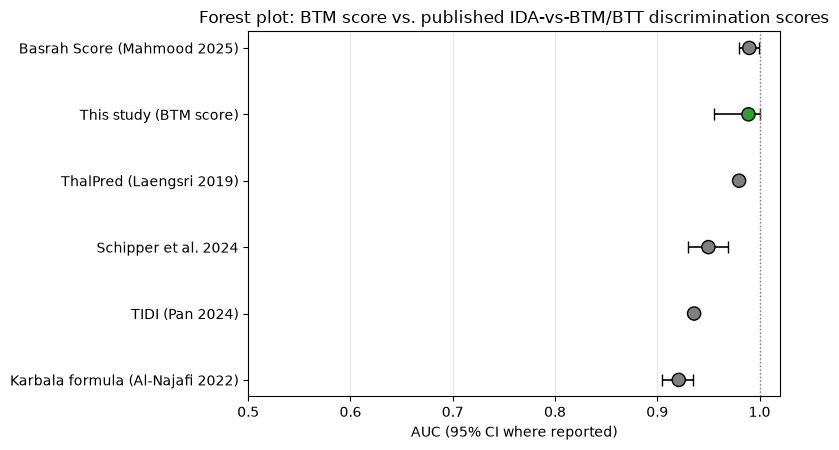

In [20]:
# ===== Forest plot: AUC with 95% CI across studies =====
plot_df = literature_df.iloc[::-1].reset_index(drop=True)  # best AUC at top
y_pos = np.arange(len(plot_df))
colors = ["#2ca02c" if s.startswith("This study") else "#7f7f7f" for s in plot_df["Study"]]

has_ci = plot_df["AUC_low"].notna()
xerr_low = (plot_df["AUC"] - plot_df["AUC_low"]).where(has_ci, 0)
xerr_high = (plot_df["AUC_high"] - plot_df["AUC"]).where(has_ci, 0)

plt.figure(figsize=(8, 0.6 * len(plot_df) + 1))
plt.errorbar(plot_df["AUC"], y_pos, xerr=[xerr_low, xerr_high], fmt="none",
             ecolor="black", elinewidth=1.2, capsize=4, zorder=1)
plt.scatter(plot_df["AUC"], y_pos, c=colors, s=90, zorder=2, edgecolor="black")
plt.yticks(y_pos, plot_df["Study"])
plt.xlabel("AUC (95% CI where reported)")
plt.xlim(0.5, 1.02)
plt.axvline(1.0, color="grey", linestyle=":", linewidth=1)
plt.title("Forest plot: BTM score vs. published IDA-vs-BTM/BTT discrimination scores")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()